In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")
print(list(uploaded.keys()))

Saving ODI_Preprocessing_GitHub_Project (1).zip to ODI_Preprocessing_GitHub_Project (1).zip
File uploaded successfully!
['ODI_Preprocessing_GitHub_Project (1).zip']


In [ ]:
import zipfile
import os

zip_file = "ODI_Preprocessing_GitHub_Project (1).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("ODI_Project")

print("Project extracted successfully!")

Project extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("ODI_Project"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

ODI_Project/ODI_Preprocessing_GitHub_Project/data/processed_dataset.csv
ODI_Project/ODI_Preprocessing_GitHub_Project/data/raw_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "ODI_Project/ODI_Preprocessing_GitHub_Project/data/processed_dataset.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (2500, 16)


,Mat,Inns,NO,Runs,HS,BF,SR,100,50,0,Start_Year,End_Year,Career_Years,Team,Runs_per_Innings,High_Average
0,463,452.0,41.0,18426.0,200.0,21367.0,86.23,49.0,96.0,20.0,1989,2012,24,INDIA,40.765487,1
1,404,380.0,41.0,14234.0,169.0,18048.0,78.86,25.0,93.0,15.0,2000,2015,16,SL,37.457895,1
2,375,365.0,39.0,13704.0,164.0,17046.0,80.39,30.0,82.0,20.0,1995,2012,18,ICC,37.545205,1
3,445,433.0,18.0,13430.0,189.0,14725.0,91.20,28.0,68.0,34.0,1989,2011,23,SL,31.016166,1
4,448,418.0,39.0,12650.0,144.0,16020.0,78.96,19.0,77.0,28.0,1998,2015,18,SL,30.263158,1


In [ ]:
# ============================================================
# ODI DATASET - COMPLETE MACHINE LEARNING TASK
# Requirements 1 to 6
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("ODI MACHINE LEARNING PROJECT")
print("=" * 60)


# ============================================================
# 1. LOAD DATASET
# ============================================================

# Your dataset is already loaded as df.
# If df is not available, uncomment the next line and use
# the correct path.

# df = pd.read_csv(
#     "ODI_Project/ODI_Preprocessing_GitHub_Project/data/processed_dataset.csv"
# )

print("\n1. DATASET INFORMATION")
print("-" * 60)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. DEFINE FEATURES AND TARGET
# ============================================================

target = "High_Average"

X = df.drop(target, axis=1)
y = df[target]

print("\nTarget column:", target)
print("Target values:")
print(y.value_counts())


# ============================================================
# 3. TRAIN / TEST SPLIT - 80/20
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n2. TRAIN / TEST SPLIT")
print("-" * 60)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Training percentage: 80%")
print("Testing percentage : 20%")


# ============================================================
# 4. PREPROCESS CATEGORICAL FEATURES
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("\nCategorical features:", categorical_features)
print("Numeric features:", numeric_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# ============================================================
# 5. BASELINE MODEL 1 - LOGISTIC REGRESSION
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)

print("\n3. LOGISTIC REGRESSION TRAINING COMPLETED")


# ============================================================
# 6. BASELINE MODEL 2 - DECISION TREE
# ============================================================

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

tree_pipeline.fit(X_train, y_train)

y_pred_dt = tree_pipeline.predict(X_test)

print("DECISION TREE TRAINING COMPLETED")


# ============================================================
# 7. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


# ============================================================
# 8. EVALUATE BOTH BASELINE MODELS
# ============================================================

lr_result = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)


# ============================================================
# 9. BASELINE COMPARISON
# ============================================================

baseline_results = pd.DataFrame([
    lr_result,
    dt_result
])

print("\n4. BASELINE MODEL COMPARISON")
print("-" * 60)

display(baseline_results)


# ============================================================
# 10. CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================================

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. CONFUSION MATRIX - DECISION TREE
# ============================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. SELECT BEST BASELINE MODEL
# ============================================================

if lr_result["F1-Score"] >= dt_result["F1-Score"]:

    best_baseline_name = "Logistic Regression"
    best_baseline_pipeline = logistic_pipeline
    best_baseline_prediction = y_pred_lr

else:

    best_baseline_name = "Decision Tree"
    best_baseline_pipeline = tree_pipeline
    best_baseline_prediction = y_pred_dt


print("\n5. BEST BASELINE MODEL")
print("-" * 60)
print("Best model:", best_baseline_name)


# ============================================================
# 13. HYPERPARAMETER TUNING
# ============================================================

print("\n6. HYPERPARAMETER TUNING")
print("-" * 60)

if best_baseline_name == "Logistic Regression":

    param_grid = {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    }

else:

    param_grid = {
        "model__criterion": [
            "gini",
            "entropy"
        ],
        "model__max_depth": [
            3,
            5,
            7,
            10,
            None
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__min_samples_leaf": [
            1,
            2,
            4
        ]
    }


grid_search = GridSearchCV(
    estimator=best_baseline_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))


# ============================================================
# 14. EVALUATE TUNED MODEL
# ============================================================

tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

tuned_result = evaluate_model(
    "Tuned " + best_baseline_name,
    y_test,
    y_pred_tuned
)


# ============================================================
# 15. FINAL MODEL COMPARISON
# ============================================================

final_results = pd.DataFrame([
    lr_result,
    dt_result,
    tuned_result
])

print("\n7. FINAL MODEL COMPARISON")
print("=" * 60)

display(final_results)


# ============================================================
# 16. SAVE RESULTS AS CSV
# ============================================================

final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("\nSaved:")
print("final_model_comparison.csv")


# ============================================================
# 17. CONFUSION MATRIX - TUNED MODEL
# ============================================================

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Confusion Matrix - Tuned " +
    best_baseline_name
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_tuned_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

print("\n8. TUNED MODEL CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)


# ============================================================
# 19. SAVE BEST/TUNED MODEL
# ============================================================

joblib.dump(
    tuned_model,
    "best_tuned_model.pkl"
)

print("\nSaved:")
print("best_tuned_model.pkl")


# ============================================================
# 20. CREATE SHORT REPORT AUTOMATICALLY
# ============================================================

best_final_row = final_results.loc[
    final_results["F1-Score"].idxmax()
]

report = f"""
============================================================
ODI DATASET - MACHINE LEARNING PROJECT REPORT
============================================================

1. OBJECTIVE
------------
The objective of this project is to build supervised
machine learning models to predict the High_Average target
using the preprocessed ODI dataset.

2. DATASET
----------
Number of records: {df.shape[0]}
Number of columns: {df.shape[1]}

3. TRAIN-TEST SPLIT
-------------------
The dataset was divided using an 80/20 split.

Training samples: {len(X_train)}
Testing samples: {len(X_test)}

4. BASELINE MODELS
-------------------
Two classification models were trained:

1. Logistic Regression
2. Decision Tree Classifier

5. EVALUATION METRICS
----------------------
Accuracy:
Measures the overall percentage of correct predictions.

Precision:
Measures how many positive predictions were actually
positive.

Recall:
Measures how many actual positive cases were correctly
identified.

F1-Score:
Provides a balance between Precision and Recall.

These metrics were selected because High_Average is a
classification target.

6. BASELINE RESULTS
-------------------
Logistic Regression:
Accuracy  = {lr_result["Accuracy"]:.4f}
Precision = {lr_result["Precision"]:.4f}
Recall    = {lr_result["Recall"]:.4f}
F1-Score  = {lr_result["F1-Score"]:.4f}

Decision Tree:
Accuracy  = {dt_result["Accuracy"]:.4f}
Precision = {dt_result["Precision"]:.4f}
Recall    = {dt_result["Recall"]:.4f}
F1-Score  = {dt_result["F1-Score"]:.4f}

7. BEST BASELINE MODEL
----------------------
Best baseline model based on F1-Score:
{best_baseline_name}

8. HYPERPARAMETER TUNING
-------------------------
GridSearchCV with 5-fold cross-validation was used to
optimize the best-performing baseline model.

Best parameters:
{grid_search.best_params_}

Best cross-validation F1-Score:
{grid_search.best_score_:.4f}

9. TUNED MODEL RESULTS
----------------------
Model: {tuned_result["Model"]}

Accuracy  = {tuned_result["Accuracy"]:.4f}
Precision = {tuned_result["Precision"]:.4f}
Recall    = {tuned_result["Recall"]:.4f}
F1-Score  = {tuned_result["F1-Score"]:.4f}

10. CONCLUSION
--------------
The baseline models were compared using Accuracy,
Precision, Recall and F1-Score. The best-performing
baseline model was selected for hyperparameter tuning
using GridSearchCV.

The final best-performing model based on F1-Score was:

{best_final_row["Model"]}

Final F1-Score:
{best_final_row["F1-Score"]:.4f}

The confusion matrices were generated and saved as image
files for performance visualization.

============================================================
END OF REPORT
============================================================
"""

with open(
    "ML_Project_Report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)


print("\nSaved:")
print("ML_Project_Report.txt")


# ============================================================
# 21. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("ALL 6 REQUIREMENTS COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("""
Files created:

1. final_model_comparison.csv
2. confusion_matrix_logistic_regression.png
3. confusion_matrix_decision_tree.png
4. confusion_matrix_tuned_model.png
5. best_tuned_model.pkl
6. ML_Project_Report.txt
""")

ODI MACHINE LEARNING PROJECT

1. DATASET INFORMATION
------------------------------------------------------------
Dataset shape: (2500, 16)

First 5 rows:


,Mat,Inns,NO,Runs,HS,BF,SR,100,50,0,Start_Year,End_Year,Career_Years,Team,Runs_per_Innings,High_Average
0,463,452.0,41.0,18426.0,200.0,21367.0,86.23,49.0,96.0,20.0,1989,2012,24,INDIA,40.765487,1
1,404,380.0,41.0,14234.0,169.0,18048.0,78.86,25.0,93.0,15.0,2000,2015,16,SL,37.457895,1
2,375,365.0,39.0,13704.0,164.0,17046.0,80.39,30.0,82.0,20.0,1995,2012,18,ICC,37.545205,1
3,445,433.0,18.0,13430.0,189.0,14725.0,91.20,28.0,68.0,34.0,1989,2011,23,SL,31.016166,1
4,448,418.0,39.0,12650.0,144.0,16020.0,78.96,19.0,77.0,28.0,1998,2015,18,SL,30.263158,1



Columns:
['Mat', 'Inns', 'NO', 'Runs', 'HS', 'BF', 'SR', '100', '50', '0', 'Start_Year', 'End_Year', 'Career_Years', 'Team', 'Runs_per_Innings', 'High_Average']

Target column: High_Average
Target values:
High_Average
0    1313
1    1187
Name: count, dtype: int64

2. TRAIN / TEST SPLIT
------------------------------------------------------------
Training samples: 2000
Testing samples : 500
Training percentage: 80%
Testing percentage : 20%

Categorical features: ['Team']
Numeric features: ['Mat', 'Inns', 'NO', 'Runs', 'HS', 'BF', 'SR', '100', '50', '0', 'Start_Year', 'End_Year', 'Career_Years', 'Runs_per_Innings']


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

ODI MACHINE LEARNING PROJECT

DATASET
------------------------------------------------------------
Shape: (2500, 16)

Missing values:
Mat                  0
Inns                10
NO                  10
Runs                10
HS                  10
BF                  10
SR                  19
100                 10
50                  10
0                   10
Start_Year           0
End_Year             0
Career_Years         0
Team                 0
Runs_per_Innings    10
High_Average         0
dtype: int64

Target: High_Average
Target values:
High_Average
0    1313
1    1187
Name: count, dtype: int64

TRAIN-TEST SPLIT
------------------------------------------------------------
Training samples: 2000
Testing samples : 500

Categorical columns:
['Team']

Numeric columns:
['Mat', 'Inns', 'NO', 'Runs', 'HS', 'BF', 'SR', '100', '50', '0', 'Start_Year', 'End_Year', 'Career_Years', 'Runs_per_Innings']

Preprocessing completed!
Missing values will be handled automatically.

Logistic Regres

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.950,0.977477,0.915612,0.945534
1,Decision Tree,0.928,0.935065,0.911392,0.923077


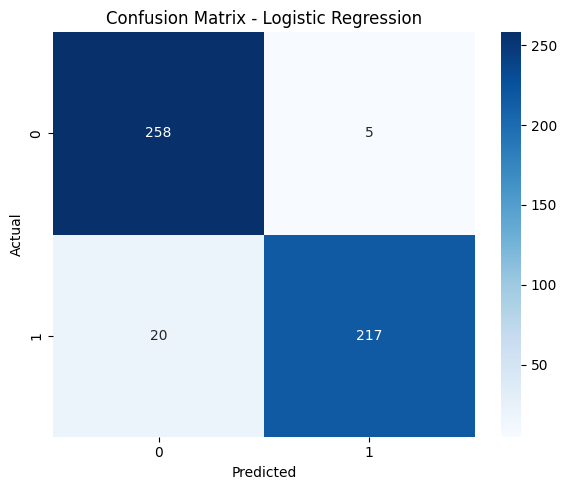

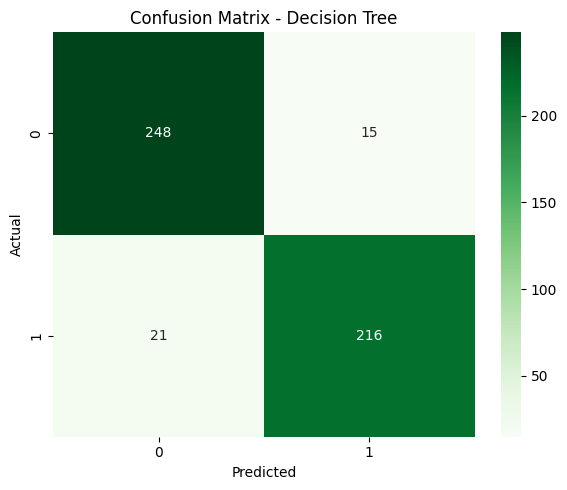


BEST BASELINE MODEL
Logistic Regression

STARTING GRID SEARCH...
Please wait...

GridSearchCV completed!

Best Parameters:
{'model__C': 100, 'model__solver': 'liblinear'}

Best Cross-Validation F1:
0.9522

Tuned Logistic Regression
Accuracy : 0.952
Precision: 0.9863
Recall   : 0.9114
F1-Score : 0.9474

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.950,0.977477,0.915612,0.945534
1,Decision Tree,0.928,0.935065,0.911392,0.923077
2,Tuned Logistic Regression,0.952,0.986301,0.911392,0.947368



Saved: final_model_comparison.csv


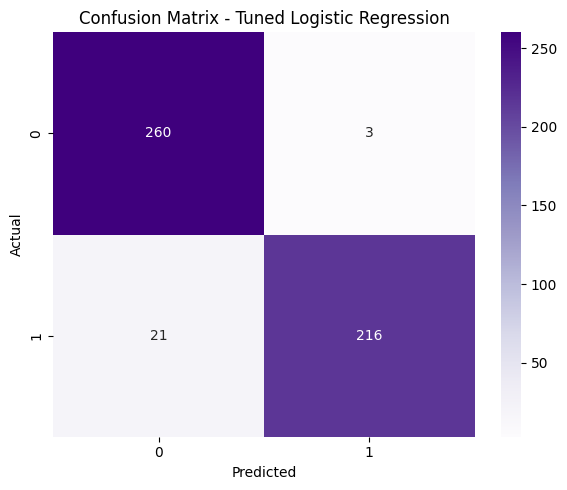


TUNED MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       263
           1       0.99      0.91      0.95       237

    accuracy                           0.95       500
   macro avg       0.96      0.95      0.95       500
weighted avg       0.95      0.95      0.95       500


Saved: best_tuned_model.pkl

Saved: ML_Project_Report.txt

ALL 6 REQUIREMENTS COMPLETED!

Files created:

1. final_model_comparison.csv
2. confusion_matrix_logistic_regression.png
3. confusion_matrix_decision_tree.png
4. confusion_matrix_tuned_model.png
5. best_tuned_model.pkl
6. ML_Project_Report.txt



In [ ]:
# ============================================================
# ODI MACHINE LEARNING PROJECT - CORRECTED VERSION
# Handles missing values (NaN) automatically
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("ODI MACHINE LEARNING PROJECT")
print("=" * 60)


# ============================================================
# STEP 1: CHECK DATASET
# ============================================================

print("\nDATASET")
print("-" * 60)

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())


# ============================================================
# STEP 2: FEATURES AND TARGET
# ============================================================

target = "High_Average"

X = df.drop(target, axis=1)
y = df[target]

print("\nTarget:", target)
print("Target values:")
print(y.value_counts())


# ============================================================
# STEP 3: 80/20 TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAIN-TEST SPLIT")
print("-" * 60)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# STEP 4: IDENTIFY NUMERIC AND CATEGORICAL COLUMNS
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("\nCategorical columns:")
print(categorical_features)

print("\nNumeric columns:")
print(numeric_features)


# ============================================================
# STEP 5: PREPROCESSING
# Handles NaN + categorical Team column
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("\nPreprocessing completed!")
print("Missing values will be handled automatically.")


# ============================================================
# STEP 6: LOGISTIC REGRESSION
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)

print("\nLogistic Regression training completed!")


# ============================================================
# STEP 7: DECISION TREE
# ============================================================

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

tree_pipeline.fit(X_train, y_train)

y_pred_dt = tree_pipeline.predict(X_test)

print("Decision Tree training completed!")


# ============================================================
# STEP 8: EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


# ============================================================
# STEP 9: EVALUATE BASELINE MODELS
# ============================================================

lr_result = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)


# ============================================================
# STEP 10: BASELINE COMPARISON
# ============================================================

baseline_results = pd.DataFrame([
    lr_result,
    dt_result
])

print("\nBASELINE MODEL COMPARISON")
print("=" * 60)

display(baseline_results)


# ============================================================
# STEP 11: CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================================

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_logistic_regression.png",
    dpi=300
)

plt.show()


# ============================================================
# STEP 12: CONFUSION MATRIX - DECISION TREE
# ============================================================

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_decision_tree.png",
    dpi=300
)

plt.show()


# ============================================================
# STEP 13: SELECT BEST BASELINE MODEL
# ============================================================

if lr_result["F1-Score"] >= dt_result["F1-Score"]:

    best_name = "Logistic Regression"
    best_pipeline = logistic_pipeline

else:

    best_name = "Decision Tree"
    best_pipeline = tree_pipeline

print("\nBEST BASELINE MODEL")
print("=" * 60)
print(best_name)


# ============================================================
# STEP 14: HYPERPARAMETER TUNING
# ============================================================

print("\nSTARTING GRID SEARCH...")
print("Please wait...")

if best_name == "Logistic Regression":

    param_grid = {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    }

else:

    param_grid = {
        "model__criterion": [
            "gini",
            "entropy"
        ],
        "model__max_depth": [
            3,
            5,
            7,
            10,
            None
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__min_samples_leaf": [
            1,
            2,
            4
        ]
    }


grid_search = GridSearchCV(
    best_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nGridSearchCV completed!")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(round(grid_search.best_score_, 4))


# ============================================================
# STEP 15: TUNED MODEL
# ============================================================

tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

tuned_result = evaluate_model(
    "Tuned " + best_name,
    y_test,
    y_pred_tuned
)


# ============================================================
# STEP 16: FINAL COMPARISON
# ============================================================

final_results = pd.DataFrame([
    lr_result,
    dt_result,
    tuned_result
])

print("\nFINAL MODEL COMPARISON")
print("=" * 60)

display(final_results)


# ============================================================
# STEP 17: SAVE RESULTS
# ============================================================

final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("\nSaved: final_model_comparison.csv")


# ============================================================
# STEP 18: TUNED MODEL CONFUSION MATRIX
# ============================================================

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Confusion Matrix - Tuned " + best_name
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_tuned_model.png",
    dpi=300
)

plt.show()


# ============================================================
# STEP 19: CLASSIFICATION REPORT
# ============================================================

print("\nTUNED MODEL CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)


# ============================================================
# STEP 20: SAVE BEST MODEL
# ============================================================

joblib.dump(
    tuned_model,
    "best_tuned_model.pkl"
)

print("\nSaved: best_tuned_model.pkl")


# ============================================================
# STEP 21: CREATE SHORT REPORT
# ============================================================

best_final = final_results.loc[
    final_results["F1-Score"].idxmax()
]

report = f"""
ODI DATASET - MACHINE LEARNING PROJECT REPORT
==============================================

1. OBJECTIVE
------------
The objective of this project is to predict the High_Average
classification target using supervised machine learning.

2. DATASET
----------
Total records: {df.shape[0]}
Total columns: {df.shape[1]}

3. TRAIN-TEST SPLIT
-------------------
80% of the data was used for training and 20% for testing.

Training samples: {len(X_train)}
Testing samples: {len(X_test)}

4. BASELINE MODELS
------------------
1. Logistic Regression
2. Decision Tree Classifier

5. EVALUATION METRICS
---------------------
Accuracy measures the overall correctness of predictions.

Precision measures how many predicted positive cases
were actually positive.

Recall measures how many actual positive cases were
correctly identified.

F1-Score provides a balance between Precision and Recall.

6. BASELINE RESULTS
-------------------
Logistic Regression:
Accuracy  = {lr_result["Accuracy"]:.4f}
Precision = {lr_result["Precision"]:.4f}
Recall    = {lr_result["Recall"]:.4f}
F1-Score  = {lr_result["F1-Score"]:.4f}

Decision Tree:
Accuracy  = {dt_result["Accuracy"]:.4f}
Precision = {dt_result["Precision"]:.4f}
Recall    = {dt_result["Recall"]:.4f}
F1-Score  = {dt_result["F1-Score"]:.4f}

7. BEST BASELINE MODEL
----------------------
{best_name}

8. HYPERPARAMETER TUNING
------------------------
GridSearchCV with 5-fold cross-validation was used.

Best parameters:
{grid_search.best_params_}

Best CV F1-Score:
{grid_search.best_score_:.4f}

9. TUNED MODEL RESULTS
----------------------
Accuracy  = {tuned_result["Accuracy"]:.4f}
Precision = {tuned_result["Precision"]:.4f}
Recall    = {tuned_result["Recall"]:.4f}
F1-Score  = {tuned_result["F1-Score"]:.4f}

10. CONCLUSION
--------------
The baseline models were evaluated using Accuracy,
Precision, Recall and F1-Score.

The best baseline model was selected and optimized
using GridSearchCV.

The best final model based on F1-Score was:

{best_final["Model"]}

Final F1-Score:
{best_final["F1-Score"]:.4f}
"""

with open(
    "ML_Project_Report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("\nSaved: ML_Project_Report.txt")


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 60)
print("ALL 6 REQUIREMENTS COMPLETED!")
print("=" * 60)

print("""
Files created:

1. final_model_comparison.csv
2. confusion_matrix_logistic_regression.png
3. confusion_matrix_decision_tree.png
4. confusion_matrix_tuned_model.png
5. best_tuned_model.pkl
6. ML_Project_Report.txt
""")

In [ ]:
# ============================================================
# STAGE 4 - CREATE GITHUB PROJECT STRUCTURE
# ============================================================

import os
import shutil
import zipfile

# ------------------------------------------------------------
# 1. CREATE FOLDERS
# ------------------------------------------------------------

os.makedirs("ML_Project_GitHub/notebooks", exist_ok=True)
os.makedirs("ML_Project_GitHub/reports", exist_ok=True)
os.makedirs("ML_Project_GitHub/images", exist_ok=True)

print("Folders created successfully!")


# ------------------------------------------------------------
# 2. CREATE requirements.txt
# ------------------------------------------------------------

requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
"""

with open(
    "ML_Project_GitHub/requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("requirements.txt created!")


# ------------------------------------------------------------
# 3. CREATE README.md
# ------------------------------------------------------------

readme = """# ODI Dataset - Machine Learning Model Evaluation and Tuning

## Project Overview

This project applies supervised machine learning techniques to
an ODI cricket dataset.

The objective is to build baseline classification models,
evaluate their performance, and improve the best-performing
model using hyperparameter tuning.

## Dataset

The preprocessed ODI dataset contains 2,500 records and
16 columns.

The target variable is:

- `High_Average`

The dataset also contains numerical cricket statistics and
categorical information such as `Team`.

## Machine Learning Workflow

The project follows these steps:

1. Load the preprocessed dataset.
2. Split the dataset into training and testing sets using an
   80/20 split.
3. Handle missing values using imputation.
4. Encode categorical variables using OneHotEncoder.
5. Train Logistic Regression as a baseline model.
6. Train Decision Tree Classifier as a second baseline model.
7. Evaluate the models using:
   - Accuracy
   - Precision
   - Recall
   - F1-Score
8. Generate confusion matrices.
9. Select the best baseline model.
10. Perform hyperparameter tuning using GridSearchCV.
11. Evaluate the tuned model.
12. Compare all model results.

## Models

### Logistic Regression

Logistic Regression is used as a simple and interpretable
baseline classification model.

### Decision Tree

Decision Tree is used as a second baseline model capable of
capturing non-linear relationships.

### Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation is used to optimize
the best-performing baseline model.

## Evaluation Metrics

### Accuracy

Measures the proportion of correct predictions.

### Precision

Measures how many predicted positive cases were actually
positive.

### Recall

Measures how many actual positive cases were correctly
identified.

### F1-Score

The F1-Score provides a balance between Precision and Recall.

## Project Structure

```text
ML_Project_GitHub/
│
├── README.md
├── requirements.txt
│
├── notebooks/
│   └── model_evaluation_and_tuning.ipynb
│
├── reports/
│   └── performance_report.md
│
└── images/
    ├── confusion_matrix_logistic_regression.png
    ├── confusion_matrix_decision_tree.png
    └── confusion_matrix_tuned_model.png

_IncompleteInputError: incomplete input (2775649947.py, line 46)

In [ ]:
import os

# Create project folder
os.makedirs("ML_Project_GitHub", exist_ok=True)

# README content
readme_text = """# ODI Dataset - Machine Learning Model Evaluation and Tuning

## Project Overview

This project uses supervised machine learning techniques
to analyze an ODI cricket dataset.

The objective is to train classification models, evaluate
their performance, and improve the best model using
hyperparameter tuning.

## Dataset

The preprocessed dataset contains 2500 records and 16 columns.

Target variable:

- High_Average

## Models Used

1. Logistic Regression
2. Decision Tree Classifier

## Train-Test Split

The dataset was divided using an 80/20 split.

- Training data: 80%
- Testing data: 20%

## Evaluation Metrics

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score

## Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation was used to tune
the best-performing baseline model.

## Visualizations

Confusion matrices were generated to evaluate model
performance.

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab
- GitHub

## Project Structure

ML_Project_GitHub/

- README.md
- requirements.txt
- notebooks/
- reports/
- images/

## Conclusion

Two baseline classification models were trained and
evaluated. The best-performing model was selected using
F1-Score and optimized using GridSearchCV.

The final tuned model was evaluated on the test dataset.
"""

# Create README.md
with open(
    "ML_Project_GitHub/README.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(readme_text)

print("README.md created successfully!")

README.md created successfully!


In [4]:
import os

# Main project folder
project = "/content/ML_Project_GitHub"

# Create required folders
os.makedirs(project, exist_ok=True)
os.makedirs(project + "/notebooks", exist_ok=True)
os.makedirs(project + "/reports", exist_ok=True)
os.makedirs(project + "/images", exist_ok=True)

# Create requirements.txt
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
"""

with open(project + "/requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

# Create README.md
readme = """# ODI Dataset - Machine Learning Model Evaluation and Tuning

## Project Overview

This project applies supervised machine learning techniques
to an ODI cricket dataset.

## Dataset

The preprocessed dataset contains 2500 records and 16 columns.

## Models Used

1. Logistic Regression
2. Decision Tree Classifier

## Train-Test Split

The dataset was divided using an 80/20 split.

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score

## Hyperparameter Tuning

GridSearchCV was used to optimize the best-performing model.

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab
- GitHub

## Project Structure

ML_Project_GitHub/

├── README.md
├── requirements.txt
├── notebooks/
├── reports/
└── images/

## Conclusion

Two baseline classification models were trained and evaluated.
The best model was selected and optimized using GridSearchCV.
"""

with open(project + "/README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("========================================")
print("PROJECT FOLDER CREATED SUCCESSFULLY!")
print("========================================")
print()
print("Location:", project)
print()
print("Files and folders:")

for item in os.listdir(project):
    print(" -", item)

PROJECT FOLDER CREATED SUCCESSFULLY!

Location: /content/ML_Project_GitHub

Files and folders:
 - images
 - reports
 - requirements.txt
 - README.md
 - notebooks
